In [1]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# 读取数据

In [2]:
ori_UserBehavior = pd.read_csv(r'UserBehavior.csv',names=['user_id','product_id','category_id','type','timestamp'],nrows = 1000000)
ori_UserBehavior.sample(50)

,user_id,product_id,category_id,type,timestamp
498720,106142,4288622,2165636,pv,1511712714
20831,10009,983972,2982027,pv,1511969171
117384,1005209,46015,3776866,pv,1511926349
17646,1000751,478880,2520377,pv,1511686819
484296,105583,631253,2520377,pv,1511704267
558489,10882,4041134,4181361,pv,1512048297
954150,126515,1417747,1611144,pv,1512113698
611451,111124,2715123,154040,pv,1511663515
555820,108685,4793473,4801426,pv,1512225816
392342,1017772,2552305,2355072,pv,1511926050


In [3]:
ori_UserBehavior.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 5 columns):
 #   Column       Non-Null Count    Dtype
---  ------       --------------    -----
 0   user_id      1000000 non-null  int64
 1   product_id   1000000 non-null  int64
 2   category_id  1000000 non-null  int64
 3   type         1000000 non-null  str  
 4   timestamp    1000000 non-null  int64
dtypes: int64(4), str(1)
memory usage: 38.1 MB


可以看到数据集共有1000000条用户行为数据，包含5个字段，其中 
 `user_id`:用户id； 
 `product_id`:产品id； 
 `category_id`:商品种类id； 
 `type`:用户行为类型；有4种，pv、fav、cart、buy; 
 `timestamp`:用户行为时间戳 

# 数据预处理

## 字段类型转换

In [4]:
# 将user_id,product_id,category_id转换为字符串类型，type转换为category
ori_UserBehavior['user_id'] = ori_UserBehavior['user_id'].astype('str')
ori_UserBehavior['product_id'] = ori_UserBehavior['product_id'].astype('str')
ori_UserBehavior['category_id'] = ori_UserBehavior['category_id'].astype('str')
ori_UserBehavior['type'] = ori_UserBehavior['type'].astype('category')

In [5]:
#将timestamp转换为时间类型
ori_UserBehavior['timestamp'] = ori_UserBehavior['timestamp'].map(lambda x: datetime.datetime.fromtimestamp(x))

In [6]:
ori_UserBehavior.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 5 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   user_id      1000000 non-null  str           
 1   product_id   1000000 non-null  str           
 2   category_id  1000000 non-null  str           
 3   type         1000000 non-null  category      
 4   timestamp    1000000 non-null  datetime64[us]
dtypes: category(1), datetime64[us](1), str(3)
memory usage: 31.5 MB


In [7]:
ori_UserBehavior.sample(10)

,user_id,product_id,category_id,type,timestamp
536386,107845,1202341,4022701,pv,2017-11-29 17:57:00
274356,101239,1676701,4145813,pv,2017-12-01 11:56:54
772561,11839,2459612,1275696,pv,2017-12-01 12:25:02
680454,1143,556990,982926,pv,2017-11-26 09:05:16
864238,122471,4905044,2705662,pv,2017-11-30 12:17:29
299388,1013525,581776,285583,pv,2017-12-01 18:44:30
627058,111834,4349365,4690421,fav,2017-12-03 21:34:52
160422,1007112,1762445,102272,pv,2017-12-01 17:45:41
895270,123888,3302046,4145813,pv,2017-11-27 12:19:24
614986,111276,4764834,2194744,pv,2017-11-29 21:53:39


In [8]:
cl_UserBehavior = ori_UserBehavior.copy()

In [9]:
#取2017-11-25到2017-12-03数据
cl_UserBehavior = cl_UserBehavior[(cl_UserBehavior['timestamp']>='2017-11-25 00:00:00') & (cl_UserBehavior['timestamp']<='2017-12-03 23:59:59')]

## 添加日期列和小时列

In [10]:
cl_UserBehavior['date'] = cl_UserBehavior['timestamp'].dt.strftime('%Y-%m-%d')
cl_UserBehavior['date'] = pd.to_datetime(cl_UserBehavior['date'])
cl_UserBehavior['hour'] = cl_UserBehavior['timestamp'].dt.hour
cl_UserBehavior.info()

<class 'pandas.DataFrame'>
Index: 999530 entries, 0 to 999999
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   user_id      999530 non-null  str           
 1   product_id   999530 non-null  str           
 2   category_id  999530 non-null  str           
 3   type         999530 non-null  category      
 4   timestamp    999530 non-null  datetime64[us]
 5   date         999530 non-null  datetime64[us]
 6   hour         999530 non-null  int32         
dtypes: category(1), datetime64[us](2), int32(1), str(3)
memory usage: 50.5 MB


选取日期后还剩下862885条数据

### 查看有无空值

In [11]:
cl_UserBehavior.isnull().sum()

user_id        0
product_id     0
category_id    0
type           0
timestamp      0
date           0
hour           0
dtype: int64

### 查看有无重复值

In [12]:
rep_nums = cl_UserBehavior.duplicated().sum()
print('\n 2.4数据重复值情况如下：\n',rep_nums)


 2.4数据重复值情况如下：
 0


### 字段统一

In [13]:
cl_UserBehavior['type'].value_counts()

type
pv      895636
cart     55447
fav      28088
buy      20359
Name: count, dtype: int64

# 数据统计信息概况

In [14]:
print('\n三、数据信息概况')

date_range_min = cl_UserBehavior['date'].min()
date_range_max = cl_UserBehavior['date'].max()
order = cl_UserBehavior[cl_UserBehavior['type'] == 'buy']['user_id'].count()
user = cl_UserBehavior['user_id'].nunique()
product = cl_UserBehavior['product_id'].nunique()
category = cl_UserBehavior['category_id'].nunique()

print(f' 3.1 用户行为和产品基本信息概况：\n订单数：{order}\n用户数：{user}\n产品数：{product}\n类目数：{category}')

print(f' 时间范围是：{date_range_min}---{date_range_max}（12.01-12.03为双12活动预热期）')


三、数据信息概况
 3.1 用户行为和产品基本信息概况：
订单数：20359
用户数：9739
产品数：398971
类目数：5793
 时间范围是：2017-11-25 00:00:00---2017-12-03 00:00:00（12.01-12.03为双12活动预热期）


# 四、流量分析

## 4.1 每日PV和UV趋势

In [15]:
date_pv = cl_UserBehavior[cl_UserBehavior['type'] == 'pv'].groupby('date')['user_id'].count()
date_uv = cl_UserBehavior[cl_UserBehavior['type'] == 'pv'].groupby('date')['user_id'].nunique()
date_pv_uv = date_pv/date_uv    #粘性指标：反映每个用户的访问深度

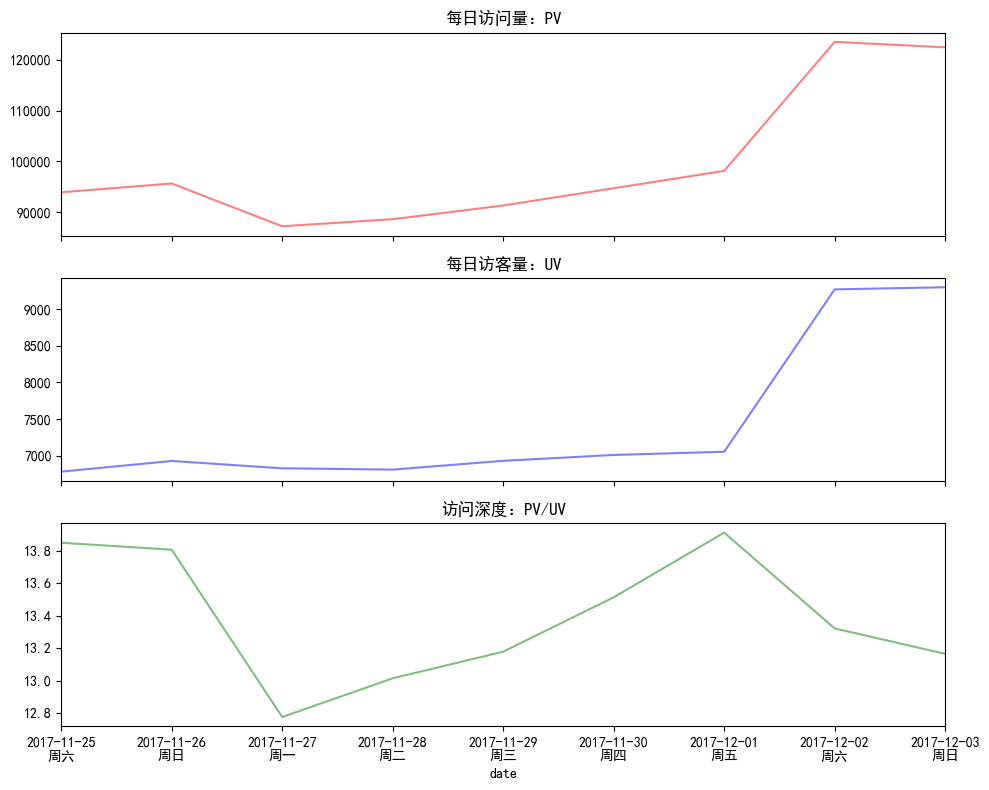

In [16]:
#绘制每天流量趋势折线图
plt.rcParams['font.sans-serif'] = ['SimHei']   #显示中文
plt.rcParams['axes.unicode_minus'] = False    #显示负号
fig,axes = plt.subplots(3,1, figsize = [10,8], sharex = True)

date_pv.plot(ax = axes[0],color = 'r', alpha = 0.5, fontsize = 10)
date_uv.plot(ax = axes[1],color = 'b', alpha = 0.5, fontsize = 10)
date_pv_uv.plot(ax = axes[2],color = 'g', alpha = 0.5, fontsize = 10)

axes[0].set_title('每日访问量：PV')
axes[1].set_title('每日访客量：UV')
axes[2].set_title('访问深度：PV/UV')

#设置x轴的刻度和双层标签
weekday = {1:'周一',2:'周二',3:'周三',4:'周四',5:'周五',6:'周六',7:'周日'}
labels = [f'{i.strftime("%Y-%m-%d")}\n{weekday[i.weekday()+1]}' for i in date_uv.index]

# 在最后一个子图上设置 x 轴刻度（因 sharex=True，会影响所有子图）
axes[2].set_xticks(date_uv.index)
axes[2].set_xticklabels(labels, fontsize=10, rotation=0)

plt.tight_layout()  # 自动调整子图间距
plt.show()

## 4.2 小时PV和UV趋势

In [17]:
hour_pv = cl_UserBehavior[cl_UserBehavior['type'] == 'pv'].groupby('hour')['user_id'].count()
hour_uv = cl_UserBehavior[cl_UserBehavior['type'] == 'pv'].groupby('hour')['user_id'].nunique()
hour_pv_uv = hour_pv/hour_uv    #粘性指标：反映每个用户的访问深度

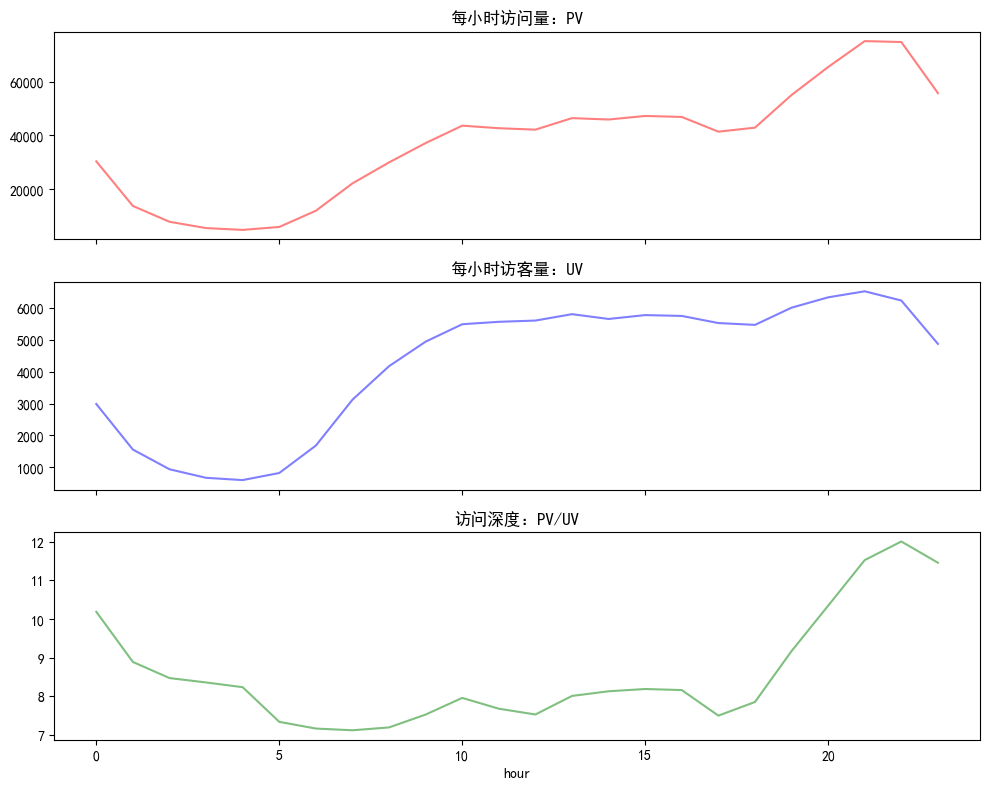

In [18]:
#绘制小时流量趋势折线图
plt.rcParams['font.sans-serif'] = ['SimHei']   #显示中文
plt.rcParams['axes.unicode_minus'] = False    #显示负号
fig,axes = plt.subplots(3,1, figsize = [10,8], sharex = True)

hour_pv.plot(ax = axes[0],color = 'r', alpha = 0.5, fontsize = 10)
hour_uv.plot(ax = axes[1],color = 'b', alpha = 0.5, fontsize = 10)
hour_pv_uv.plot(ax = axes[2],color = 'g', alpha = 0.5, fontsize = 10)

axes[0].set_title('每小时访问量：PV')
axes[1].set_title('每小时访客量：UV')
axes[2].set_title('访问深度：PV/UV')

plt.tight_layout()  # 自动调整子图间距
plt.show()

## 4.3 每天/小时的PV和UV趋势

In [19]:
date_hour_pv = cl_UserBehavior[cl_UserBehavior['type'] == 'pv'].groupby(['date','hour'])['user_id'].count()
date_hour_uv = cl_UserBehavior[cl_UserBehavior['type'] == 'pv'].groupby(['date','hour'])['user_id'].nunique()

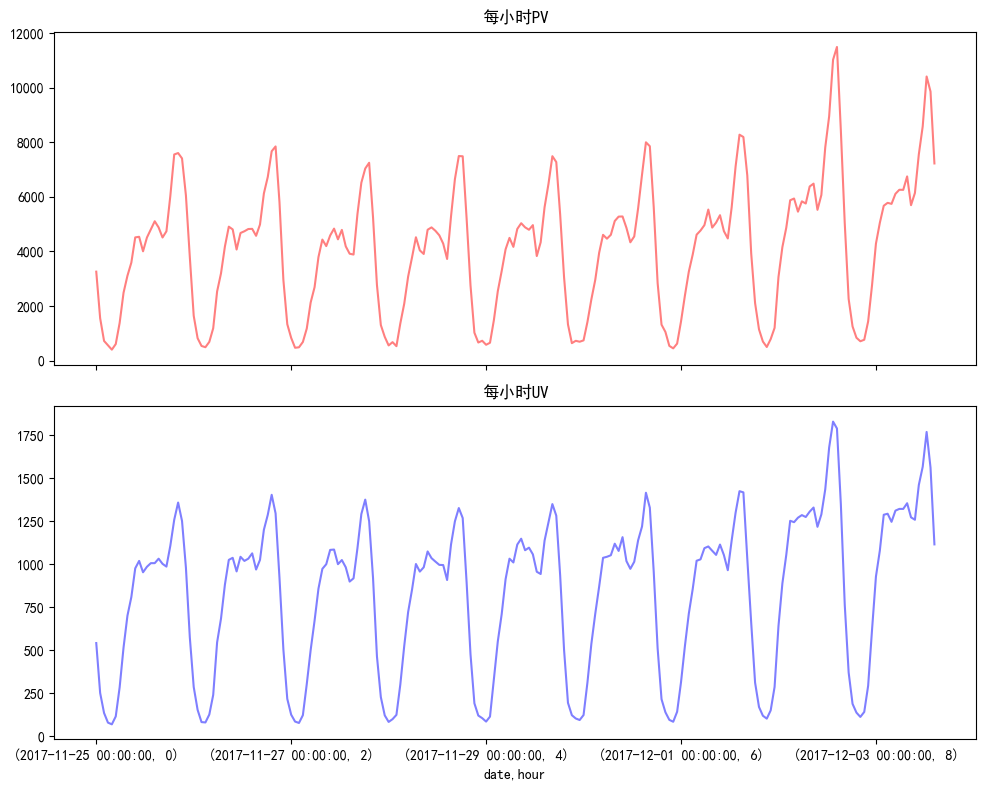

In [20]:
fig,axes = plt.subplots(2,1, figsize = [10,8], sharex = True)

date_hour_pv.plot(ax = axes[0],color = 'r', alpha = 0.5, fontsize = 10)
date_hour_uv.plot(ax = axes[1],color = 'b', alpha = 0.5, fontsize = 10)

axes[0].set_title('每小时PV')
axes[1].set_title('每小时UV')


plt.tight_layout()  # 自动调整子图间距
plt.show()

## 4.4 双12期间与平时流量对比

In [21]:
df = cl_UserBehavior.copy()

In [22]:
df_usu = df[(df['date'] >= '2017-11-25') & (df['date'] <= '2017-11-30')]
df_12 = df[(df['date'] >= '2017-12-01') & (df['date'] <= '2017-12-03')]
#双12流量
date_pv_12 = date_pv[(date_pv.index >= '2017-12-01 00:00:00') & (date_pv.index <= '2017-12-03 23:59:59')].mean()
date_uv_12 = date_uv[(date_uv.index >= '2017-12-01 00:00:00') & (date_uv.index <= '2017-12-03 23:59:59')].mean()

hour_pv_12 = (df_12[df_12['type']=='pv'].groupby('hour')['user_id'].count()/df_12['date'].nunique()).mean()
hour_uv_12 = (df_12[df_12['type']=='pv'].groupby('hour')['user_id'].nunique()/df_12['date'].nunique()).mean()

#平时流量
date_pv_usu = date_pv[(date_pv.index >= '2017-11-25 00:00:00') & (date_pv.index <= '2017-11-30 23:59:59')].mean()
date_uv_usu = date_uv[(date_uv.index >= '2017-11-25 00:00:00') & (date_uv.index <= '2017-11-30 23:59:59')].mean()

hour_pv_usu = (df_usu[df_usu['type']=='pv'].groupby('hour')['user_id'].count()/df_usu['date'].nunique()).mean()
hour_uv_usu = (df_usu[df_usu['type']=='pv'].groupby('hour')['user_id'].nunique()/df_usu['date'].nunique()).mean()

#活动期间与非活动期间的流量对比
date_pv_pct = (date_pv_12-date_pv_usu) / date_pv_usu
date_uv_pct = (date_uv_12-date_uv_usu) / date_uv_usu

hour_pv_pct = (hour_pv_12-hour_pv_usu) / hour_pv_usu
hour_uv_pct = (hour_uv_12-hour_uv_usu) / hour_uv_usu

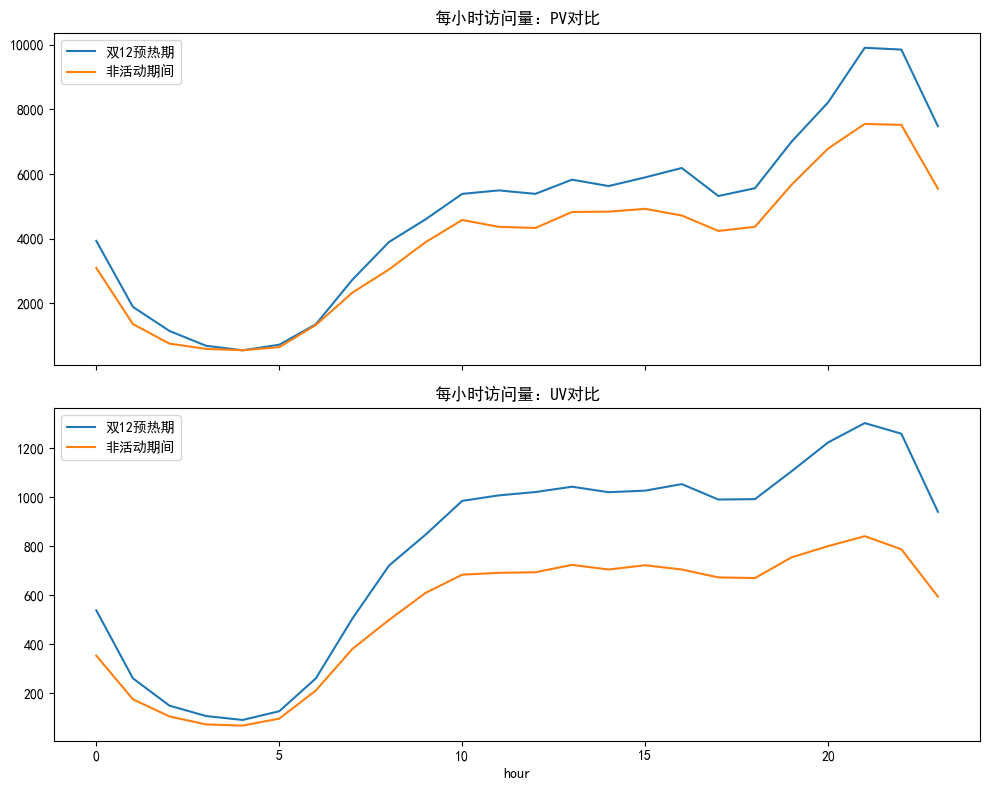

In [23]:
# 双12活动期间与非活动期间的流量趋势折线图对比
# pv对比
fig,axes = plt.subplots(2,1, figsize = [10,8], sharex = True)
hour_pv_1 = df_12[df_12['type']=='pv'].groupby('hour')['user_id'].count()/df_12['date'].nunique()
hour_pv_2 = df_usu[df_usu['type']=='pv'].groupby('hour')['user_id'].count()/df_usu['date'].nunique()

hour_pv_1.plot(ax = axes[0],label = '双12预热期')
hour_pv_2.plot(ax = axes[0],label = '非活动期间')
axes[0].set_title('每小时访问量：PV对比')
axes[0].legend()

#UV对比
hour_uv_1 = df_12[df_12['type']=='pv'].groupby('hour')['user_id'].nunique()/df_12['date'].nunique()
hour_uv_2 = df_usu[df_usu['type']=='pv'].groupby('hour')['user_id'].nunique()/df_usu['date'].nunique()
hour_uv_1.plot(ax = axes[1],label = '双12预热期')
hour_uv_2.plot(ax = axes[1],label = '非活动期间')
axes[1].set_title('每小时访问量：UV对比')
axes[1].legend()

plt.tight_layout()  # 自动调整子图间距
plt.show()

In [24]:
print(f' 4.6 流量分析信息如下：'
      f'\n 非活动：每日平均PV:{round(date_pv_usu,2)}，每日平均UV:{round(date_uv_usu,2)};'
      f'\n 双12预热期：每日平均PV:{round(date_pv_12,2)}，每日平均UV:{round(date_uv_12,2)};'
      f'\n 双12每日平均PV比平时提升:{round(100*date_pv_pct,2)}%，每日平均UV比平时提升:{round(100*date_uv_pct,2)}%;'

      f'\n 非活动：小时平均PV:{round(hour_pv_usu,2)}，小时平均UV:{round(hour_uv_usu,2)};'
      f'\n 双12预热期：小时平均PV:{round(hour_pv_12,2)}，小时平均UV:{round(hour_uv_12,2)};'
      f'\n 双12小时平均PV比平时提升:{round(100*hour_pv_pct,2)}%，小时平均UV比平时提升:{round(100*hour_uv_pct,2)}%\n')

 4.6 流量分析信息如下：
 非活动：每日平均PV:91923.0，每日平均UV:6881.33;
 双12预热期：每日平均PV:114699.33，每日平均UV:8541.67;
 双12每日平均PV比平时提升:24.78%，每日平均UV比平时提升:24.13%;
 非活动：小时平均PV:3830.12，小时平均UV:526.4;
 双12预热期：小时平均PV:4779.14，小时平均UV:774.69;
 双12小时平均PV比平时提升:24.78%，小时平均UV比平时提升:47.17%



In [25]:
print(f' 4.7 用户访问深度：\n'
      f'非活动期每日：用户平均访问：{round(date_pv_usu/date_uv_usu.mean(),2)}次；每小时：用户平均访问：{round(hour_pv_usu/hour_uv_usu.mean(),2)}次;\n'
        f' 双12期间每日：用户平均访问：{round(date_pv_12/date_uv_12.mean(),2)}次；每小时：用户平均访问：{round(hour_pv_12/hour_uv_12.mean(),2)}次')

 4.7 用户访问深度：
非活动期每日：用户平均访问：13.36次；每小时：用户平均访问：7.28次;
 双12期间每日：用户平均访问：13.43次；每小时：用户平均访问：6.17次


4.8 从每日流量趋势看出，呈现明显的日周期性波动：
1. 整体流量显著增长：双12预热期相较于非活动期间，日均PV和UV分别提升了24.78% 和24.13%，表明预热活动有效吸引了更多用户访问，整体流量规模明显扩大；
2. 用户结构变化：小时UV增长远超小时PV；小时平均UV提升达47.17%，而小时平均PV仅提升24.78%。这说明预热期每小时内的独立访客数量增长更为迅猛，但每位访客在该小时内的平均访问次数（即小时访问深度）却从平时的7.28次下降至6.17次。
   这种“访客数大增、人均访问频次下降”的现象，可能源于预热期吸引了大量新用户或低频用户，他们的访问行为较为浅层；也可能是活动使得用户访问时间分布更均匀，避免了高峰期的集中点击。
3. 日访问深度保持稳定，用户日均粘性未变：每日用户平均访问深度（PV/UV）几乎持平：平时13.36次，预热期13.43次。这说明尽管小时深度下降，但用户在一天内的总访问次数并未减少，意味着用户可能在一天中分散了访问时段，保持了日均活跃度不变。
4. 业务启示：预热活动有效拉新：UV的显著提升说明活动触达了更多用户，尤其在小时间粒度上表现突出。
需关注用户质量：新用户可能停留时间短、点击少，后续应通过个性化推荐或引导提升其访问深度。
流量调度更均衡：若服务器压力因小时UV激增而增大，需做好扩容准备；同时可针对分散时段优化内容推送，维持用户活跃。

综上，双12预热期在扩大用户规模方面成效显著，但用户访问行为呈现“广覆盖、浅交互”的特点，后续运营需平衡拉新与促活策略。

4.9 从每小时流量趋势看出，PV和UV整体趋势依然一致，访问深度也存在周期性波动：
1. 18点开始，pv和uv都呈上升趋势，尤其pv直线提升，pv/uv比率提升明显，该事件普遍是下班/放学时间，用户有更多时间浏览电商平台购物；
2. 22点后pv开始下降明显，22点到早上5点pv/uv持续降低，用户陆续休息；
3. 5点后pv和uv逐渐上升，用户早起，uv增加明显，但pv相对uv提升不多，用户访问深度依然下降；
4. 10点开始达到流量小高峰，10点到18点pv和uv曲线平稳，波动不明显，浏览电商平台时间较少

# 五、用户分析

## 5.1 用户行为分析

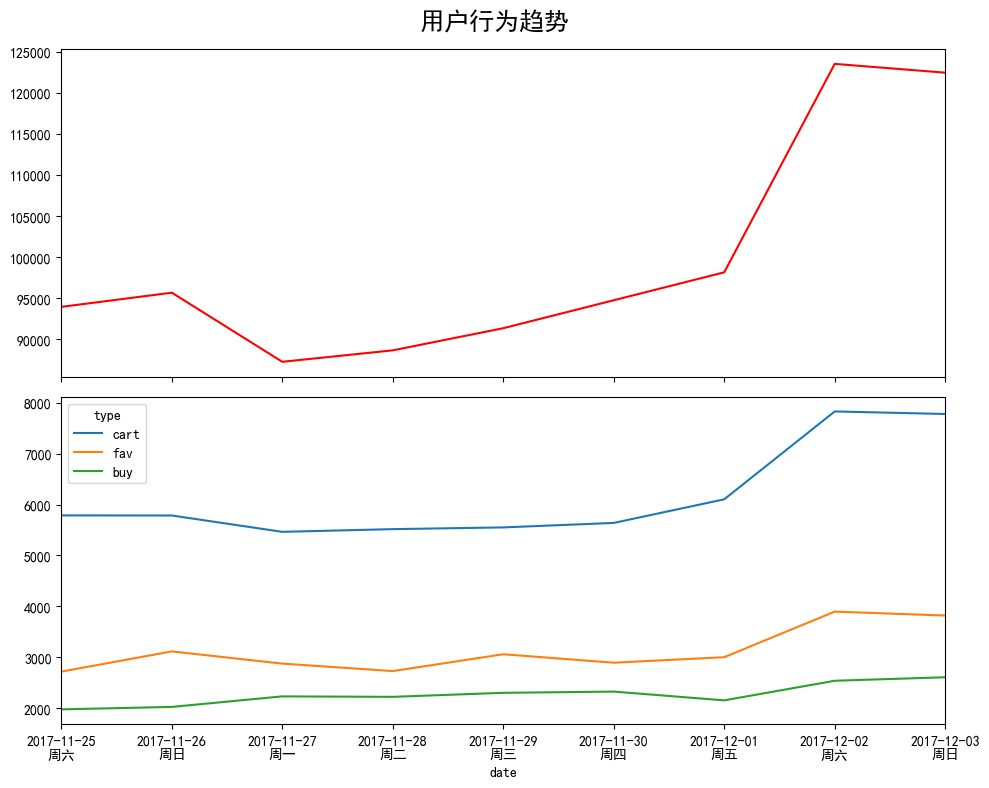

In [26]:
# 取用户行为-日期表
df_behavior = df.groupby(['date', 'type'])['user_id'].count().unstack()

#创建用户行为折线图
fig,axes = plt.subplots(2,1,figsize = [10,8],sharex = True)
fig.suptitle('用户行为趋势',fontsize = 18, fontweight = 'bold')

#因为pv量级较大，与其他行为分开绘制
df_behavior['pv'].plot(ax= axes[0],color = 'r')
df_behavior[['cart','fav','buy']].plot(ax= axes[1])

#设置x轴的双层标签，显示出星期
weekday = {1:'周一',2:'周二',3:'周三',4:'周四',5:'周五',6:'周六',7:'周日'}
labels = [f'{i.strftime("%Y-%m-%d")}\n{weekday[i.weekday()+1]}' for i in df_behavior.index]

# 在最后一个子图上设置 x 轴刻度（因 sharex=True，会影响所有子图）
axes[1].set_xticks(df_behavior.index)
axes[1].set_xticklabels(labels, fontsize=10, rotation=0)

plt.tight_layout()  # 自动调整子图间距
plt.show()

### 5.1.1 用户行为类型趋势分析

5.1.1 用户行为类型趋势分析：
- 双12活动预热使用户pv提升明显，cart加购量也呈上升趋势，而fav收藏量和buy购买量提升幅度相对较低；
- 可能有以下几个原因：
 1. 预热期通常以曝光和吸引用户关注为主，商家会通过预告、折扣信息等方式刺激用户浏览和加购，但真正的优惠往往在活动当天才释放。因此，用户倾向于在预热期“逛”和“加购”商品，等待双12当天再下单，导致购买行为滞后。
 2. 加购（加入购物车）是购买前最后一步，用户将商品加入购物车通常意味着较高的购买意向，而收藏更多是“标记感兴趣”，决策深度较浅。在活动预热阶段，用户为节省当天抢购时间，会优先将心仪商品加购，而非单纯收藏，因此加购量增长更明显。
 3. 消费者普遍预期双12当天有更大折扣或叠加优惠（如跨店满减、红包），因此即使已决定购买，也会刻意延迟支付，等待活动正式开启。这解释了为什么购买量在预热期没有同步大幅增长。
 4. 许多商家在预热期会推出“加购抽奖”“加购有礼”等活动，鼓励用户将商品加入购物车，这直接刺激了加购数据，但对收藏和购买的拉动有限。
 5. 若预热商品多为高单价、需比较的品类（如大家电、数码产品），用户决策周期长，预热期仅完成浏览和加购，购买需进一步考虑；而低价、冲动型消费品则可能直接在预热期成交，但整体比例较低。
 6. PV和加购是即时行为，预热期流量涌入会直接推高这两项指标；而购买行为受支付流程、优惠券领取等环节影响，且部分用户可能选择在预热期最后一天或活动当天集中支付，导致购买增幅相对平缓。

综上，预热期呈现**高流量、高加购、低转化**的特征，符合电商大促的典型用户行为路径，后续需结合活动当天的数据进一步验证转化效率。
另一种方式：
1. **商家运营层面**
   - 活动策略引导：预热期商家通过“加购有礼”“预售加购”等活动，直接激励用户将商品加入购物车，而收藏和购买行为未被同等刺激。
   - 营销节奏设计：双12的核心优惠（如跨店满减、大额券）往往集中在活动当天释放，导致用户在预热期只浏览和加购，等待最佳购买时机。
   - 流量推广侧重：预热期广告投放以曝光和引流为主，吸引大量新用户，这些用户更倾向于浅层浏览（PV），但尚未建立足够的购买信任。
2. **用户本身层面**
   - 心理预期：用户普遍认为双12当天折扣更大，形成“持币观望”心态，即使有意向也延迟支付，使得购买量增幅滞后。
   - 行为习惯：加购比收藏更接近购买决策，用户为方便活动日快速下单，优先将商品加入购物车，而非单纯收藏；新用户或低频用户则多停留在浏览阶段。
   - 决策周期：对于高单价或非必需品，用户需要时间比价、研究，预热期仅完成信息收集，购买决策延后。
3. **产品自身层面**
   - 商品属性：若预热商品多为高价值、耐用消费品（如家电、数码），用户决策周期长，预热期难以直接转化；而低单价、冲动型商品可能已被即时购买，但整体占比较小。
   - 优惠力度感知：预热期展示的优惠（如预告价）可能不够吸引人，或需要凑单才能享受，用户倾向于等待最终折扣确认后再购买。
   - 收藏功能定位：收藏更多是“标记兴趣”或“长期种草”，与即时购买意愿关联较弱，因此活动对收藏的拉动作用天然低于加购。     

### 5.1.2 用户行为组合构成

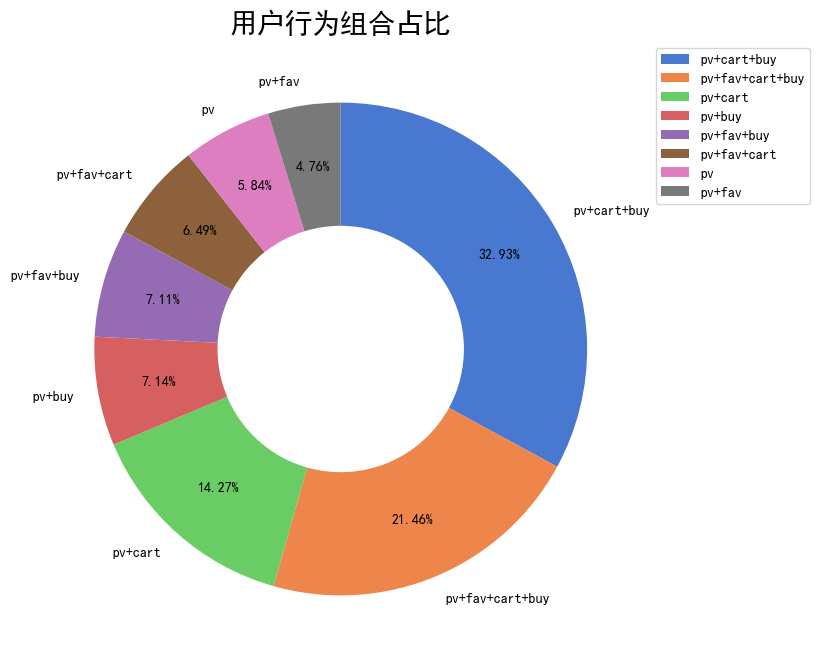

In [27]:
# 用户行为分组
df_user = df.groupby(['user_id','type']).size().unstack()
df_user = df_user.reindex(columns = ['pv','fav','cart','buy'])    #重置列索引顺序

#只分析有浏览pv行为的用户；基于本数据集只是9天数据，可能该时间段之前有浏览行为，故剔除没有pv的用户；
df_user = df_user[df_user['pv'].notna()]

#将空值替换为0，其他值替换1
df_user_status = df_user.map(lambda x:0 if np.isnan(x) else 1)

#创建行为组合字典
behavior_combine = {'1000':'pv',
                    '1100':'pv+fav',
                    '1010':'pv+cart',
                    '1001':'pv+buy',
                    '1110':'pv+fav+cart',
                    '1011':'pv+cart+buy',
                    '1101':'pv+fav+buy',
                    '1111':'pv+fav+cart+buy'
                   }
#各行为组合转为组合状态并值计数，将当前行的每个元素转换为字符串，使用join进行拼接，生成原始行为模式字符串，后替换应用为文字标签
type_status = df_user_status.apply(lambda x: ''.join(map(str,x)),axis =1).map(behavior_combine)
type_status = type_status.value_counts().sort_values(ascending = False)

#绘制各行为组合占比的环形图
fig,ax = plt.subplots(figsize = [10,8])

type_status.plot(kind = 'pie', wedgeprops = dict(width = 0.5),autopct = '%1.2f%%',#设置环形宽度（饼图变为环形）,标签样式
                startangle = 90,counterclock = False, pctdistance = 0.75,ax=ax, 
                 colors = sns.color_palette('muted',8))#开始角度90度，顺时针方向，百分比标签距离圆心的距离

plt.axis('off')  #隐藏坐标轴，防止坐标轴出现none
plt.legend(loc='upper left',bbox_to_anchor = (1,1))  # 图例放在图表外右上方
plt.title('用户行为组合占比', fontsize = 20)
plt.show()

**用户行为路径分析（序列分析）**：
1. 用户行为组合中，'pv+cart+buy'是核心转化路径，占比32.93%，是行为组合中占比最高的；
2. “pv+fav+cart+buy”深度行为组合占比达21.46%；这类用户决策更谨慎且用户群体规模较大；
3. 单一行为的pv，即仅浏览的用户行为较少，占比为5.84%；说明用户不会仅停留在浅行为阶段，浏览后通常都会进一步转化为加购或购买；
4. “加购”是关键行为；包含加购行为组合总占比高达75.15%，加购是连接浏览和购买的核心行为；
5. “收藏”意向不强；'pv+fav'和'pv+fav+buy'占比分别为4.76%、7.11%，从fav到buy的转化链路还需加强；

**针对以上分析总结给出运营优化建议：**
1. 强化“加购”作为转化枢纽的作用：
- 加购引导：在商品详情页显著位置设置“加入购物车”按钮，并配合弹窗提示“加购后可享受满减提醒”“加购抽奖”等激励，鼓励用户完成加购。
- 购物车营销：在购物车页面增加“凑单推荐”“限时优惠”“库存紧张提示”等动因，刺激用户从加购走向下单。
- 跨渠道提醒：对加购后未购买的用户，通过站内信、推送或短信发送购物车商品降价或库存预警，召回用户完成支付。
2. 提升“收藏”行为的转化效率：收藏夹运营：将用户的收藏夹打造为“心愿单”，定期推送收藏商品降价通知、补货提醒、同类商品推荐，并增加“一键加购”功能，缩短收藏到购买的路径。
3. 针对深度决策用户（“pv+fav+cart+buy”）提供精细化服务：为这类用户提供商品对比功能，支持将收藏或加购的商品进行参数、价格、评价的直观对比，辅助决策。
4. 激活“仅浏览”用户，减少流失：
- 浏览中插引导：在用户浏览一定时间或页面后，适时弹出“您可能喜欢”“限时优惠”等浮层，吸引其点击加购或收藏。
- 新客优惠弹窗：对识别为新用户的浏览者，自动弹出新人专享券或包邮券，刺激首次互动。
- 个性化推荐：根据浏览历史在页面底部或侧边栏推荐高关联商品，增加用户点击加购的概率。

5. 结合不同路径优化流量分发与补贴策略：
- 路径标签化：在用户行为数据库中打上路径标签（如“直接购买型”“加购犹豫型”“收藏种草型”），后续推送差异化文案和优惠。
- 补贴差异化：对“pv+cart”但未购买的用户，可发放小额支付券；对“pv+fav”用户，推送收藏商品满减券；对“pv+fav+cart+buy”高价值用户，给予会员积分加速等长期权益。
- A/B测试：针对不同路径实验不同的页面布局和引导语，找到提升各环节转化率的最佳实践。

6. 持续监测漏斗，动态优化：建立从“浏览→收藏/加购→购买”的转化漏斗，定期分析各环节流失率，结合用户行为组合的变化趋势，及时调整运营策略。例如，若“pv+cart”到“pv+cart+buy”的转化率下降，需重点优化购物车页面的支付引导。

### 5.1.3 用户行为转化

In [32]:
df_user_cvr = df_user.map(lambda x:0 if np.isnan(x) else x)  #用户行为转化表，空值替换为0

#计算用户行为转化率，因为购买的路径可能是pv-buy，不考虑cart-fav转化率
pv_cart_cvr = df_user_cvr.sum()['cart']/df_user_cvr.sum()['pv']
pv_fav_cvr = df_user_cvr.sum()['fav']/df_user_cvr.sum()['pv']
pv_buy_cvr = df_user_cvr.sum()['buy']/df_user_cvr.sum()['pv']
cart_buy_cvr = df_user_cvr.sum()['buy']/df_user_cvr.sum()['cart']
fav_buy_cvr = df_user_cvr.sum()['buy']/df_user_cvr.sum()['fav']

In [33]:
print(f'5.1.3 用户行为转化分析：')

print(f'用户“浏览-加购”的转化率为：{pv_cart_cvr*100:.2f}%\n'
     f'用户“浏览-收藏”的转化率为：{pv_fav_cvr*100:.2f}%\n'
     f'用户“浏览-购买”的转化率为：{pv_buy_cvr*100:.2f}%\n'
     f'用户“收藏-购买”的转化率为：{fav_buy_cvr*100:.2f}%\n'
     f'用户“加购-购买”的转化率为：{cart_buy_cvr*100:.2f}%\n')
#加购-购买、收藏-购买转化率会比现实偏高，一部分购买量来自直接浏览或收藏转化

5.1.3 用户行为转化分析：
用户“浏览-加购”的转化率为：6.15%
用户“浏览-收藏”的转化率为：3.11%
用户“浏览-购买”的转化率为：2.26%
用户“收藏-购买”的转化率为：72.40%
用户“加购-购买”的转化率为：36.65%



**由用户转化漏斗数据可知：**
1. 转化漏斗衰减明显，93.85%用户浏览后无加购；96.89%用户浏览后无收藏；
2. 加购-购买转化不足，加购用户中仅36.65%最终购买，且实际数据比该值还低；
**给出优化建议：**
1. 提高加购率：加购率低可能原因价格缺乏竞争力；商品主图/详情页不够吸引，设置适宜价格和提升产品视觉美观；加购按钮旁显示“已有XX人加购”；首次加购送优惠券；
2. 提高收藏率：收藏按钮更显眼；收藏后享专属优惠；
3. 提高加购-购买转化率：购物车满减优惠、限时优惠、降价提醒等；购物车库存紧张提示；加购后24小时未购买推送提醒

In [40]:
#双12活动预热期与平时的转化对比

#新建is_12列，判断是否是双12活动并分组聚合
df['is_12'] = ((df['date'] >= '2017-11-25') & (df['date'] <= '2017-11-30')).map({True:'no',False:'yes'})
df_12 = df.groupby(['is_12','type']).size().unstack().reindex(columns=['pv','fav','cart','buy'])

#新建列，计算转化率
df_12['pv-cart-cvr'] = (100*df_12['cart']/df_12['pv']).round(2)
df_12['pv-fav-cvr'] = (100*df_12['fav']/df_12['pv']).round(2)
df_12['pv-buy-cvr'] = (100*df_12['buy']/df_12['pv']).round(2)
df_12['cart-buy-cvr'] = (100*df_12['buy']/df_12['cart']).round(2)

In [41]:
print(f'双12活动预热期与平时对比数据如下：\n{df_12}')

print(f'- 双12活动预热期的“浏览-购买”、“浏览-收藏”的转化率对比平时变化不明显，其中“浏览-加购”略有提升；\n'
      f'- 双12活动预热期的“加购-购买”转化率低于平时转化率；\n'
      f'- 该现象与用户行为趋势分析一致，双12活动预热期用户的浏览和加购行为前置，加购率高于平时；\n'
      f'- 而用户购买行为可能后置到正式双12活动，故在双12预热期购买率低于平时；\n')

双12活动预热期与平时对比数据如下：
type       pv    fav   cart    buy  pv-cart-cvr  pv-fav-cvr  pv-buy-cvr  \
is_12                                                                     
no     551538  17376  33737  13067         6.12        3.15        2.37   
yes    344098  10712  21710   7292         6.31        3.11        2.12   

type   cart-buy-cvr  
is_12                
no            38.73  
yes           33.59  
- 双12活动预热期的“浏览-购买”、“浏览-收藏”的转化率对比平时变化不明显，其中“浏览-加购”略有提升；
- 双12活动预热期的“加购-购买”转化率低于平时转化率；
- 该现象与用户行为趋势分析一致，双12活动预热期用户的浏览和加购行为前置，加购率高于平时；
- 而用户购买行为可能后置到正式双12活动，故在双12预热期购买率低于平时；



## 5.2 用户价值分析

### 5.2.1 用户购买频次分析

In [42]:
print(f'5.2.1 用户购买频次分析')
buy_count = df[df['type'] == 'buy'].groupby('user_id')['type'].count()  #每个用户购买次数
#buy_count = df[df['type'] == 'buy']['user_id'].nunique()   #产生购买行为的用户数量

#计算购买用户占比
buy_user_pct = len(buy_count)/df['user_id'].nunique()
print(f'- 活跃用户中购买用户占比为：{100*buy_user_pct:.2f}%；其中购买用户数为：{len(buy_count)}；')

buy_1 = len(buy_count[buy_count.values == 1])/ len(buy_count)
print(f'- 购买用户中仅购买一次用户占比：{100*buy_1:.2f}%; 购买用户再复购占比为：{100-100*buy_1:.2f}%')

#计算整体平均购买频次
active_user_buy = buy_count.values.sum()/df['user_id'].nunique()

print(f'- 活跃用户的平均购买次数为：{active_user_buy:.2f}次')
print(f'- 购买用户的平均购买次数为：{buy_count.values.mean():.2f}次')

5.2.1 用户购买频次分析
- 活跃用户中购买用户占比为：68.68%；其中购买用户数为：6689；
- 购买用户中仅购买一次用户占比：33.79%; 购买用户再复购占比为：66.21%
- 活跃用户的平均购买次数为：2.09次
- 购买用户的平均购买次数为：3.04次


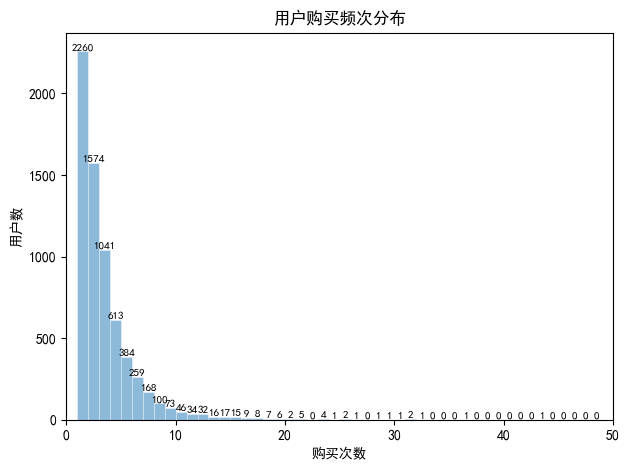

In [50]:
#购买频次的直方图分布
fig,ax = plt.subplots()

counts, bins, patches = ax.hist(buy_count, bins=range(1, 50), alpha=0.5, edgecolor='white', linewidth=0.5)
#添加数据标签
#ax.bar_label(ax.containers[0])
# 只对高度大于等于20的柱子显示标签
bars = patches
labels = [int(h) if h >= 0 else '' for h in counts]
ax.bar_label(bars, labels=labels, fontsize=8)

plt.title('用户购买频次分布')
plt.ylabel('用户数')
plt.xlabel('购买次数')
plt.xlim([0,50])
plt.tight_layout()
plt.show()

**购买转化与复购表现：**
1. 活跃用户中近7成（68.68%）完成购买，说明活跃用户的消费转化意愿较强；
2. 购买用户中，复购用户超6成（66.21%），复购基础好；
3. 活跃用户平均购买2.09次，购买用户平均3.04次，体现复购用户对整体频次的拉升作用；

**用户消费频次分布特征：**
1. 购买频次呈幂律分布；低频次用户占主导，消费（1-3）次用户占比达72.88%，大部分的用户消费次数仅在3次及以下；
   - 针对仅购买1次用户，可通过“首单后触达”（如复购优惠券，个性化商品推荐）降低决策门槛，推动其二次购买转化；
   - （2-10）次的低频次复购人数，可设计“阶梯式激励”（如购买次数越多优惠越大），引导其提升购买频次；
2. 消费次数在10次以上的用户数递减，总用户占比仅2.56%，长尾效应明显，高频复购人群基数小；高频次用户需提供专属权益（如VIP服务，定制化服务）强化留存，同时挖掘拉新潜力，放大影响力；

### 5.2.2 用户购买周期分析

In [74]:
#5.2.2 用户购买周期分析

#取购买行为数据并按日期去重
df_buy = df[df['type'] == 'buy'].drop_duplicates(subset=['user_id','date'],keep = 'first')
buy_day = df_buy.groupby('user_id')['date'].apply(lambda x:x.sort_values().diff(1).dropna().dt.days)
#buy_day是一个序列，包含userid第一级，df-buy的索引第二级，和时间间隔数
buy_day = buy_day.reset_index(name='buy_day_diff')
#buy_day通过重置索引从序列转变为df，原来的索引均变为列，之前的第二级索引变为level1
print(f'5.2.2 用户购买周期分析')

print(f'用户平均购买周期为：{buy_day['buy_day_diff'].mean():.2f}天')

5.2.2 用户购买周期分析
用户平均购买周期为：2.39天


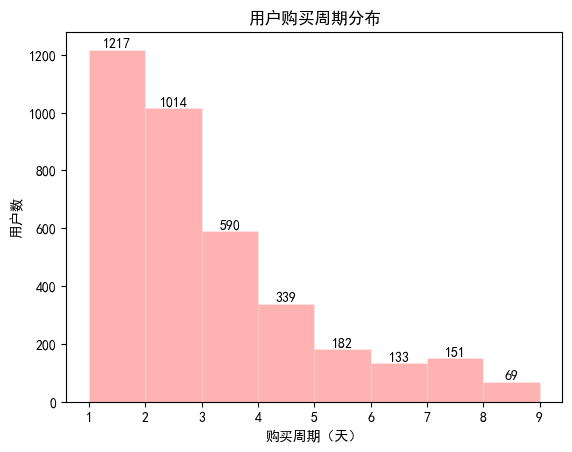

In [75]:
#用户购买周期分布
buy_day = buy_day.groupby('user_id')['buy_day_diff'].mean()  #每个用户平均购买周期,因为用户不只买了一次，间隔时间不一样

fig,ax = plt.subplots()
plt.hist(buy_day,bins = range(1,10), color = 'r',alpha = 0.3, edgecolor = 'white', linewidth = 0.5)

ax.bar_label(ax.containers[0])
plt.title('用户购买周期分布')
plt.ylabel('用户数')
plt.xlabel('购买周期（天）')
plt.show()

**由用户购买周期分布可知：**
1. 购买周期为1-2天的用户数占比60.38%，超一半用户的消费周期在2天内；这类用户复购意愿强，可推出专属权益（如多买多返券，积分翻倍），进一步强化复购习惯，同时引导向更高客单价转化；
2. 周期越长，用户数整体递减；随着购买周期3天到8天的延申，用户数量呈下降趋势，仅7天周期用户数略有回升；针对购买周期3-4天的用户，需通过精准触达（如个性化商品推荐和复购提醒）缩短购买周期，避免流失；
3. 长周期用户基数少，购买周期在5天以上的用户数均低于200，属于低频复购群体；该类用户复购动力弱，可设计唤醒活动（如专属折扣或新品使用福利），刺激再次消费；

### 5.2.3 用户留存率

In [78]:
#次日留存率
retention_1 = df.groupby(['date','user_id'])['type'].count().reset_index() #type全包含，干什么都算留存
retention_2 = df.groupby(['date','user_id'])['type'].count().reset_index()
retention = pd.merge(retention_1,retention_2,on = ['user_id'],suffixes=('_1','_2'))
retention

,date_1,user_id,type_1,date_2,type_2
0,2017-11-25,1,6,2017-11-25,6
1,2017-11-25,1,6,2017-11-26,1
2,2017-11-25,1,6,2017-11-27,8
3,2017-11-25,1,6,2017-11-28,7
4,2017-11-25,1,6,2017-11-29,8
...,...,...,...,...,...
514909,2017-12-03,12860,2,2017-11-28,4
514910,2017-12-03,12860,2,2017-11-29,5
514911,2017-12-03,12860,2,2017-11-30,18
514912,2017-12-03,12860,2,2017-12-02,10


In [80]:
#筛选次日留存记录并分组统计
retention = retention[(retention['date_2']-retention['date_1']).dt.days == 1]
retention_group = retention.groupby('date_1')['user_id'].count()
retention_group

date_1
2017-11-25    5518
2017-11-26    5529
2017-11-27    5523
2017-11-28    5569
2017-11-29    5704
2017-11-30    5766
2017-12-01    7148
2017-12-02    9404
Name: user_id, dtype: int64

In [81]:
#每天的用户数
user_day = df.groupby('date')['user_id'].nunique()
#计算次日留存率（删除空值）
user_retention_1 = (retention_group/user_day).dropna().reset_index(name='retention_rate')
user_retention_1

,date_1,retention_rate
0,2017-11-25,0.790998
1,2017-11-26,0.775673
2,2017-11-27,0.786080
3,2017-11-28,0.791951
4,2017-11-29,0.798768
5,2017-11-30,0.796079
6,2017-12-01,0.983219
7,2017-12-02,0.982962


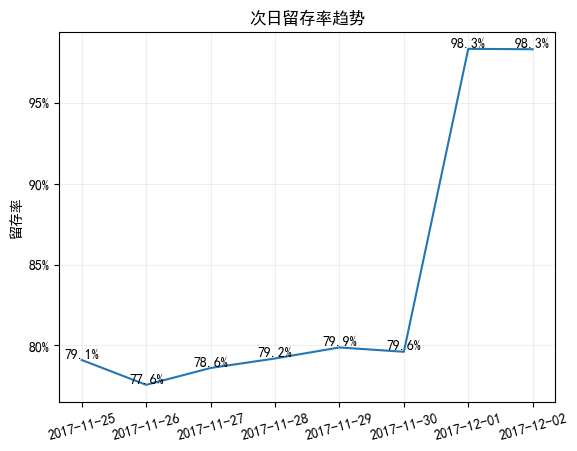

In [85]:
#绘制次日留存率趋势折线图
import matplotlib as mpl
from matplotlib import ticker  #导入ticker 模块
fig,ax = plt.subplots()
plt.plot(user_retention_1['date_1'],user_retention_1['retention_rate']*100)
plt.title('次日留存率趋势')
plt.ylabel('留存率')
plt.grid(alpha = 0.2) #网格线透明度
plt.xticks(rotation = 15) #x 轴刻度旋转角度（避免日期标签重叠）
#设置y轴百分号标签
#pct_label = ticker.FormatStrFormatter('%.0f%%')  #创建格式化器，将 y 轴数值显示为整数百分比
#ax.yaxis.set_major_formatter(pct_label)  #将格式化器应用到 ax 的 y 轴，使刻度标签自动添加 % 符号且不显示小数
ax.yaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))

#设置折线图的数据标签
for x, y in zip(user_retention_1['date_1'], user_retention_1['retention_rate']):
    plt.text(x,y*100,f'{y*100:.1f}%',ha='center',va= 'bottom')  #在坐标 (x, y*100) 处添加文本，内容为保留一位小数的百分比，水平居中，底部对齐（即文本位于点上方）

plt.show()

**用户留存率分析：**
从2017-11-25至2017-12-02的次日留存率数据可看出：
- 活动前（11.25-30）留存率处于77.6%-79.9%的低位区间，整体波动较小，表现平稳；双12预热期（12.1-2）留存率陡增至98.3%，并保持稳定活动预热对次日留存的拉动效果显著；
1. 建议复用活动预热的留存策略，本次预热玩法契合用户需求，可总结运营手段复用到后续大促或节点活动中；
2. 延长活动留存周期：需跟踪双12正式及活动后的留存走势，避免预热期留存冲高后快速回落，通过活动后长尾福利，如返场权益维持用户粘性；

### 5.2.4 用户RFM分层

In [89]:
#因数据集中没有消费金额维度数据，这里的M就用（pv+cart+buy）频次代替
df_user = df.groupby(['user_id','type']).size().unstack().reindex(columns= ['pv','fav','cart','buy'])
df_user = df_user[(df_user['pv'].notna()) & (df_user['buy'].notna())]
df_user = df_user.map(lambda x:0 if np.isnan(x) else x).reset_index()
df_user

type,user_id,pv,fav,cart,buy
0,100,84.0,6.0,0.0,8.0
1,1000001,34.0,0.0,0.0,1.0
2,1000011,91.0,8.0,0.0,2.0
3,100002,84.0,7.0,0.0,1.0
4,1000027,12.0,0.0,5.0,2.0
...,...,...,...,...,...
6657,128572,81.0,19.0,3.0,3.0
6658,128573,27.0,0.0,4.0,2.0
6659,128590,128.0,2.0,0.0,4.0
6660,128591,91.0,13.0,8.0,2.0


In [92]:
#获得用户购买的最近日期
df_time_max = df[df['type'] == 'buy'].groupby('user_id')['date'].max().reset_index()
df_time_max

,user_id,date
0,100,2017-11-28
1,1000001,2017-12-03
2,1000011,2017-11-25
3,100002,2017-11-30
4,1000027,2017-12-03
...,...,...
6684,128572,2017-12-03
6685,128573,2017-11-30
6686,128590,2017-12-02
6687,128591,2017-12-02


In [100]:
#表连接
user_rfm = pd.merge(df_user,df_time_max,on=['user_id'],how = 'left')
user_rfm['m'] = user_rfm['pv']+ user_rfm['fav'] + user_rfm['cart']
user_rfm['f'] = user_rfm['buy']
user_rfm['r'] = (df_time_max['date'].max() - user_rfm['date']).dt.days  #距离当日最近一次消费间隔
user_rfm

,user_id,pv,fav,cart,buy,date,m,f,r
0,100,84.0,6.0,0.0,8.0,2017-11-28,90.0,8.0,5
1,1000001,34.0,0.0,0.0,1.0,2017-12-03,34.0,1.0,0
2,1000011,91.0,8.0,0.0,2.0,2017-11-25,99.0,2.0,8
3,100002,84.0,7.0,0.0,1.0,2017-11-30,91.0,1.0,3
4,1000027,12.0,0.0,5.0,2.0,2017-12-03,17.0,2.0,0
...,...,...,...,...,...,...,...,...,...
6657,128572,81.0,19.0,3.0,3.0,2017-12-03,103.0,3.0,0
6658,128573,27.0,0.0,4.0,2.0,2017-11-30,31.0,2.0,3
6659,128590,128.0,2.0,0.0,4.0,2017-12-02,130.0,4.0,1
6660,128591,91.0,13.0,8.0,2.0,2017-12-02,112.0,2.0,1


In [102]:
#rfm与对应维度的均值比较，记为1或0
rfm = user_rfm[['r','f','m']].copy()
rfm['r'] = rfm['r'] <= rfm['r'].mean()  #对每一列计算该列的平均值，然后将每个元素与该平均值比较，结果是一个布尔值（True/False）
rfm['f'] = rfm['f'] >= rfm['f'].mean()
rfm['m'] = rfm['m'] >= rfm['m'].mean()

rfm = rfm.map(lambda x: 1 if x else 0)
rfm

,r,f,m
0,0,1,0
1,1,0,0
2,0,0,0
3,0,0,0
4,1,0,0
...,...,...,...
6657,1,0,0
6658,0,0,0
6659,1,1,1
6660,1,0,1


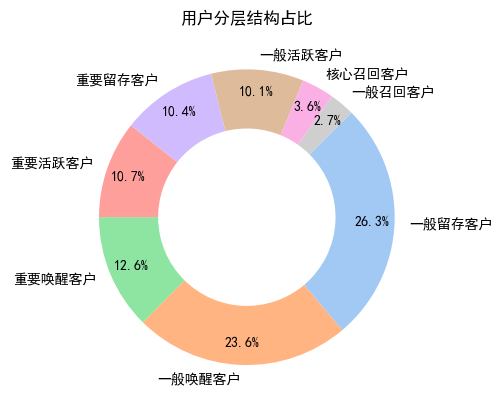

In [109]:
#用户分层定义
status = {#因pv+cart+fav频次代替m消费金额，所以rfm的用户分层名称需基于用户行为逻辑
    '111':'重要活跃客户',
    '110':'一般活跃客户',
    '101':'重要留存客户',
    '100':'一般留存客户',
    '011':'核心召回客户',
    '010':'一般召回客户',
    '001':'重要唤醒客户',
    '000':'一般唤醒客户',
}

#用户分层统计
rfm = rfm.apply(lambda x: ''.join(map(str,x)),axis=1).map(status).value_counts()

#绘制环形图
fig,ax = plt.subplots()
rfm.plot(kind ='pie', ax= ax, wedgeprops = dict(width = 0.4),colors = sns.color_palette('pastel',8),
        autopct = '%1.1f%%', startangle = 45,counterclock = False, pctdistance = 0.85)

plt.axis('off')
plt.title('用户分层结构占比')
plt.show()

**5.2.4 用户分层结构分析**
1. 一般留存用户和一般唤醒用户 是占比最高的两个群体，两者占比合计接近50%，该类用户基数大但分层标签“一般”，忠诚度低，购买频次低可通过个性化运营，推低价爆款/小品类轻决策商品及平台活动普适推送来提升活跃度；
2. “重要类用户”中重要唤醒用户、重要活跃用户和重要留存用户，占比相对均衡，合计33.7%；高价值潜力群体，需强化留存策略如专属权益、个性化优惠和推荐；
3. 召回用户占比低，合计仅6.3%；该类用户近期不活跃，有流失风险，优化召回触达渠道、发送上新推送或“3天内浏览得券”回归福利等

# 六、产品及品类分析

## 6.1 产品分析

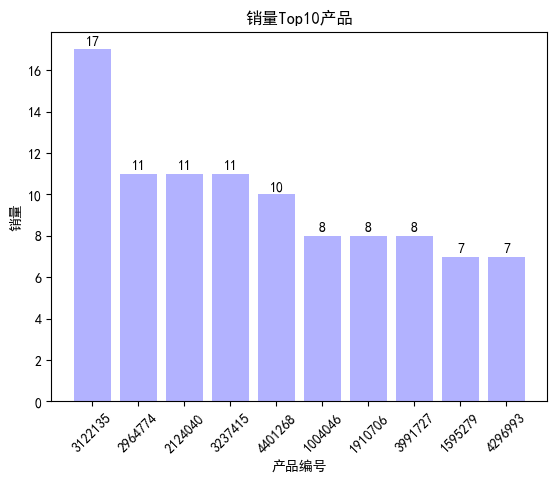

In [121]:
df_product = df.groupby(['product_id','type']).size().unstack().reindex(columns=['pv','fav','cart','buy']).sort_values(by='buy', ascending=False)
# 将缺失值（无购买记录）填充为0
#df_product = df_product.fillna(0)
#取销量top10产品
df_product_top10 = df_product[:10].copy()

#绘制top10产品柱状图
fig,ax = plt.subplots()
#x轴是数值类型遍历为字符串
plt.bar([str(i) for i in df_product_top10.index],df_product_top10['buy'],color = 'b',alpha = 0.3)
#添加数据标签，(x,y+0.1）表示文本放置位置，y+0.1使文本略高于柱顶，避免重叠
for x,y in enumerate(df_product_top10['buy']):plt.text(x,y+0.1,f'{y:.0f}',ha = 'center',va = 'bottom')

plt.title('销量Top10产品')
plt.xlabel('产品编号')
plt.ylabel('销量')
plt.xticks(rotation=45)
plt.show()

In [122]:
print(f'产品销量描述统计：\n{df_product.buy.describe()}')

产品销量描述统计：
count    17565.000000
mean         1.159066
std          0.546493
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         17.000000
Name: buy, dtype: float64


**从销量描述统计和top10产品可知：**
销量分布极其集中，超75%的产品销量仅为1；top1产品销量仅17，销量差距不明显；top（2-10）产品的销量相对集中（7-11）区间，内部差异小；
1. 激活低销量产品，对销量为1的产品，筛选符合用户偏好的产品，通过关联推荐（搭配高销量产品）或低价试销等方式提升曝光及转化；
2. 优化产品结构，淘汰无潜力的低销量产品；
3. 对top产品增加流量倾斜（如首页推荐、活动主会场），尝试打造为小爆款，拉动品类整体销量；
4. 分析top产品的共性特征（如价格、品类），复用成功逻辑到其他产品；
5. 优化资源配置，针对不同销量产品分层匹配差异化资源；

## 6.2 类目分析

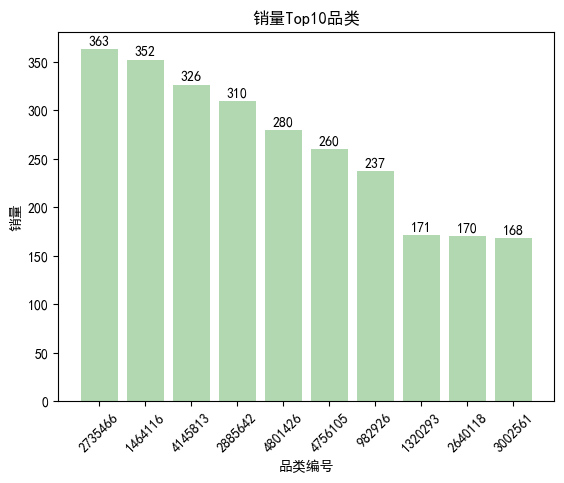

In [126]:
df_category = df.groupby(['category_id','type']).size().unstack().reindex(columns=['pv','fav','cart','buy']).sort_values('buy', ascending=False)

df_category_10 = df_category[:10].copy()
fig,ax =plt.subplots()
plt.bar([str(i) for i in df_category_10.index],df_category_10['buy'],color = 'g',alpha = 0.3)

for x,y in enumerate(df_category_10['buy']):
    plt.text(x,y+2,f'{y:.0f}',ha='center',va='bottom')

plt.title('销量Top10品类')
plt.xlabel('品类编号')
plt.ylabel('销量')
plt.xticks(rotation = 45)
plt.show()

In [127]:
print(f'品类销量描述统计：\n{df_category.buy.describe()}')

品类销量描述统计：
count    2513.000000
mean        8.101472
std        22.757629
min         1.000000
25%         1.000000
50%         2.000000
75%         6.000000
max       363.000000
Name: buy, dtype: float64


**品类销量两极分化：**
75%分位数的品类销量为6；大多数品类处于低销量区间；均值8，标准差22.7，最大值363，体现少数头部品类高销量大幅拉高整体均值，品类间销量差异极大；
1. 对top5头部品类加大资源投入，维持高销量优势；挖掘头部类目的用户需求，拓展品类下的产品矩阵，进一步放大品类价值；
2. 针对腰部top（6-10）品类，测试流量扶持+活动激励策略，推动其向头部类目升级；
3. 激活低销量品类，筛选符合市场趋势的潜力品类，通过品类关联、精准营销等提升销量；优化品类结构，淘汰无增长潜力品类；
4. 分析top类目的成功因素（如产品特性、用户群体），将经验复用至低销量类目中；

### 6.2.1 品类购买率分析

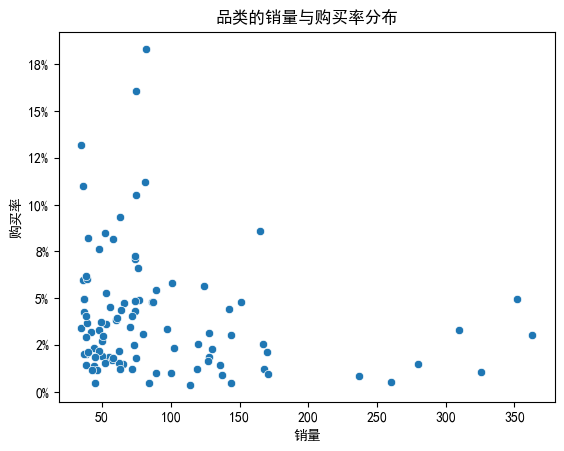

In [128]:
#新建列，计算加购率（pv-cart)和购买率（pv-buy),可能加购量没有购买量多，掩埋数据真实性
df_category['pv-cart-cvr'] = (100*df_category['cart']/df_category['pv']).round(2)
df_category['pv-buy-cvr'] = (100*df_category['buy']/df_category['pv']).round(2)

#切片销量前100品类
df_category_100 = df_category[:100].copy()

#按购买率和加购率降序
df_category_100.sort_values(['pv-cart-cvr','pv-buy-cvr'],ascending=False,inplace = True)

#绘制销量与购买率的散点图
fig,ax = plt.subplots()
sns.scatterplot(data=df_category_100, x='buy',y='pv-buy-cvr')

#设置y轴坐标轴的百分号显示
pct_label = ticker.FormatStrFormatter('%.0f%%')
ax.yaxis.set_major_formatter(pct_label)

plt.title('品类的销量与购买率分布')
plt.xlabel('销量')
plt.ylabel('购买率')
plt.show()

**6.2.1 品类销量与购买率分析：**
- 从品类销量与购买率分布看出，两者无明显正相关关系，未呈现同步增长的趋势，说明高销量不等价于高购买率；
- 高销量品类的购买率偏低，销量大于200的品类中，购买率普遍低于5%，高销量品类的购买转化率较弱；
- 低销量品类的购买率波动大，销量小于50的品类中，部分购买率高达12%-18%，多数集中在0-5%区间，购买率差异显著。
1. 针对“低销量+高购买率”品类，加大流量投入，提升销量规模；分析其高购买率的原因，复用至其他低转化品类；
2. 针对“高销量+低购买率”品类，优化转化链路，增加信任背书，提升转化；筛选品类下的高转化产品，聚焦资源推广，带动整体购买率提升

### 6.2.2 双12预热期对比平时的品类销量差异

In [143]:
top_12 = pd.pivot_table(df[df['type'] == 'buy'],index = ['category_id'],columns = ['is_12'],values = 'user_id',aggfunc = 'count' )
top_12

is_12,no,yes
category_id,,
1004392,2.0,NaN
1008362,7.0,7.0
1009182,11.0,2.0
1009667,NaN,3.0
1010656,4.0,3.0
...,...,...
992700,1.0,NaN
99507,1.0,NaN
996449,1.0,1.0


In [144]:
top_12['no'] = (top_12['no']/6).round(0)
top_12['yes'] = (top_12['yes']/3).round(0)
print(f' {top_12['no']},{top_12['yes']}')

 category_id
1004392    0.0
1008362    1.0
1009182    2.0
1009667    NaN
1010656    1.0
          ... 
992700     0.0
99507      0.0
996449     0.0
996587     0.0
999755     1.0
Name: no, Length: 2513, dtype: float64,category_id
1004392    NaN
1008362    2.0
1009182    1.0
1009667    1.0
1010656    1.0
          ... 
992700     NaN
99507      NaN
996449     0.0
996587     1.0
999755     1.0
Name: yes, Length: 2513, dtype: float64


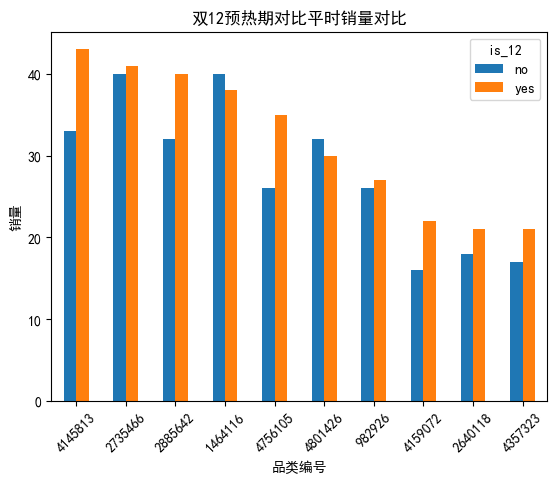

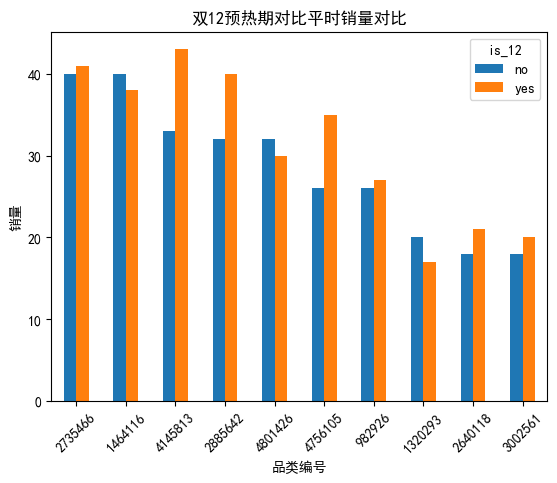

In [148]:
top_12_12 = top_12.sort_values(['yes','no'],ascending = [False,False])
top_12_usu = top_12.sort_values(['no','yes'],ascending = [False,False])
#循环两次，第一次按 'yes' 降序取前10赋值给 data，第二次按 'no' 降序取前10再次赋值给 data
for i in['yes','no']:
    data = top_12.sort_values([i], ascending = [False]).head(10)

    fig,ax = plt.subplots()
    data.plot(kind = 'bar', ax=ax)
    
    plt.title('双12预热期对比平时销量对比')
    plt.xlabel('品类编号')
    plt.ylabel('销量')
    plt.xticks(rotation = 45)
    plt.show()

**6.2.2 类目销量差异分析（双12预热期与平时对比）**
1. 多数品类预热期销量高于平时；其中4145813和4756105品类在预热期显著高于平时销量，说明活动对类目销量的拉动效果普遍有效；
   - 针对预热期销量高增类目，加大这些品类的库存储备，避免缺货；
   - 增加其预热期活动曝光量（增加推荐广告位），进一步放大销量增长效应；
2. 品类间的活动响应差异大，部分类目如2735466预热期与平时销量差距极小；部分类目如1464116预热期销量低于平时；活动对这些品类刺激不足；
   - 针对低响应类目，调整活动策略，增加专属折扣、搭配赠品等展示，提升用户感知；
   - 精准触达人群，分析这些类目的目标用户，定向推送活动信息，减少无效触达；
   - 关联高响应品类做组合推荐，借助高热度类目带动其流量和销量；

### 6.2.3 类目分层

In [152]:
#对类目的浏览、加购和收藏、购买三个维度进行类目分层；思路同RFM类似，将RFM三个维度分别替换为pv，cart/fav,buy
df_category['cart/fav'] = df_category['cart'] + df_category['fav']
category_type = df_category[['pv','cart/fav','buy']].copy()

#类目的用户行为量与中位数比较，大于等于中位数记为1，否则为0
category_type['pv_status'] = category_type['pv'] >= category_type['pv'].median()
category_type['cart_fav_status'] = category_type['cart/fav'] >= category_type['cart/fav'].median()
category_type['buy_status'] = category_type['buy'] >= category_type['buy'].median()

for i in ['pv_status','cart_fav_status','buy_status']:
    category_type[i] = category_type[i].apply(lambda x: '1' if x == True else '0')

In [150]:
category_type.describe()

type,pv,cart/fav,buy
count,5701.000000,1871.000000,2513.000000
mean,157.101561,43.011224,8.101472
std,1248.605067,180.528403,22.757629
min,1.000000,2.000000,1.000000
25%,3.000000,4.000000,1.000000
50%,12.000000,10.000000,2.000000
75%,51.000000,23.000000,6.000000
max,47770.000000,3830.000000,363.000000


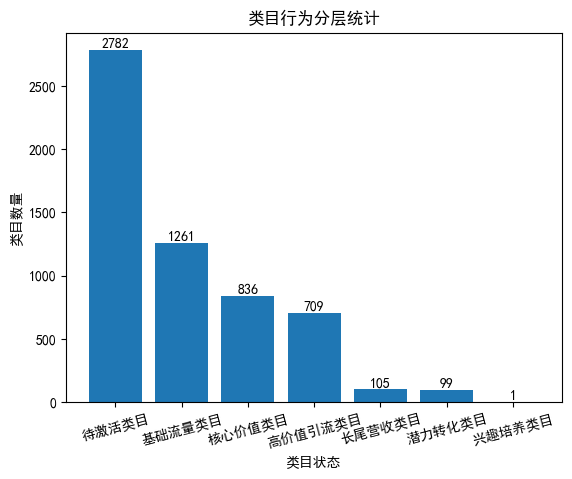

In [155]:
#定义类目分层属性，对pv，cart/fav,buy三个维度变量，将大于本维度中位数记为1否则0
status={#pv 代表流量热度，用户关注度；cart/fav代表用户兴趣度；buy代表类目商业价值
    '111':'核心价值类目',
    '110':'潜力转化类目',
    '101':'高价值引流类目',
    '100':'基础流量类目',
    '011':'高潜力小众类目',
    '010':'兴趣培养类目',
    '001':'长尾营收类目',
    '000':'待激活类目'    
}

category_type['type_3'] = category_type['pv_status'] + category_type['cart_fav_status'] +category_type['buy_status']
category_type['type_3'] = category_type['type_3'].map(status)

#类目分层计数统计
category_status = category_type['type_3'].value_counts().sort_values(ascending = False)

#绘制类目行为分层柱状图
fig,ax = plt.subplots()
bar2 = plt.bar(category_status.index, category_status.values)
plt.bar_label(bar2, labels = category_status.values)

plt.title('类目行为分层统计')
plt.xlabel('类目状态')
plt.ylabel('类目数量')
plt.xticks(rotation = 15)
plt.show()

**6.2.3 类目行为分层分析**
结合RFM模型的分层规则，对类目行为分层：
1. 待激活类目（即R/F/M均低）数量最多，其次基础流量类目（即R/F/M为100），两者合计占比近70%（69.8%），类目规模大且价值转化空间较大；
   - 待激活类目的价值评估：分析类目商品的市场需求，判断是否优化或者下降；
   - 待激活类目的轻量测试：小范围投放低价引流款，测试用户反馈；暂时减少运营资源投入，资源收缩优先保障高价值类目；
   - 基础流量类目的兴趣测试，投放类目下的低价试用品，引导用户体验；在高转化类目页面关联推荐本类目商品，借势转化；
2. 核心价值类目（即R/F/M均高）是高价值类目，但占比不足15%（14.4%）；
   - 资源倾斜，优先分配首页推荐、搜索置顶等核心流量位；权益强化，开通专属服务和优先发货等权益，巩固用户粘性；
   - 结合类目受众推出衍生新品，扩大营收范围；

### 6.2.4 用户购买决策时长分析

In [165]:
#取各类目下各用户行为的首次时间
category_time = df.groupby(['category_id','user_id','type'])['date'].min().unstack().reindex(columns=['pv','fav','cart','buy']).reset_index()
category_time

type,category_id,user_id,pv,fav,cart,buy
0,1000959,1000912,2017-11-26,NaT,NaT,NaT
1,1000959,1002306,2017-11-27,NaT,NaT,NaT
2,1000959,1006307,2017-11-27,NaT,NaT,NaT
3,1001152,1010017,2017-12-02,NaT,NaT,NaT
4,1003726,10086,2017-12-02,NaT,NaT,NaT
...,...,...,...,...,...,...
239441,999980,1004080,2017-11-30,NaT,NaT,NaT
239442,999980,100501,2017-12-02,NaT,NaT,NaT
239443,999980,100525,NaT,2017-12-03,NaT,NaT
239444,999980,1005916,2017-12-01,NaT,NaT,NaT


In [166]:
#筛选pv和buy不为空的记录以及首购时间大于等于首次浏览时间的记录
category_time.dropna(subset = ['pv','buy'],inplace =True)
category_time = category_time[category_time['buy'] >= category_time['pv']]  

#新增决策时长列
category_time['pv_buy_time'] = (category_time['buy'] - category_time['pv']).dt.days

#计算各个类目的购买平均决策时长
category_time_avg = category_time.groupby('category_id')['pv_buy_time'].agg(['count','mean'])
category_time_avg = category_time_avg.sort_values('count',ascending =False)

print(f'类目总平均决策时长为： {category_time['pv_buy_time'].mean():.2f}天\n')

类目总平均决策时长为： 1.10天



In [158]:
category_time

type,category_id,user_id,pv,fav,cart,buy,pv_buy_time
5,1004392,1005616,2017-11-25,NaT,2017-11-25,2017-11-25,0
12,1004392,116028,2017-11-28,NaT,NaT,2017-11-28,0
40,1008362,1002449,2017-12-02,NaT,NaT,2017-12-02,0
48,1008362,100377,2017-11-29,NaT,NaT,2017-11-29,0
62,1008362,1006597,2017-11-29,NaT,NaT,2017-11-30,1
...,...,...,...,...,...,...,...
239393,999755,1015460,2017-12-01,NaT,NaT,2017-12-01,0
239397,999755,104166,2017-11-27,2017-11-27,NaT,2017-11-28,1
239407,999755,108227,2017-11-28,NaT,NaT,2017-11-28,0
239412,999755,111691,2017-11-26,NaT,NaT,2017-11-26,0


In [167]:
category_time_avg.describe()

,count,mean
count,2194.000000,2194.000000
mean,6.140383,0.774819
std,17.427130,1.143317
min,1.000000,0.000000
25%,1.000000,0.000000
50%,2.000000,0.333333
75%,5.000000,1.000000
max,264.000000,8.000000


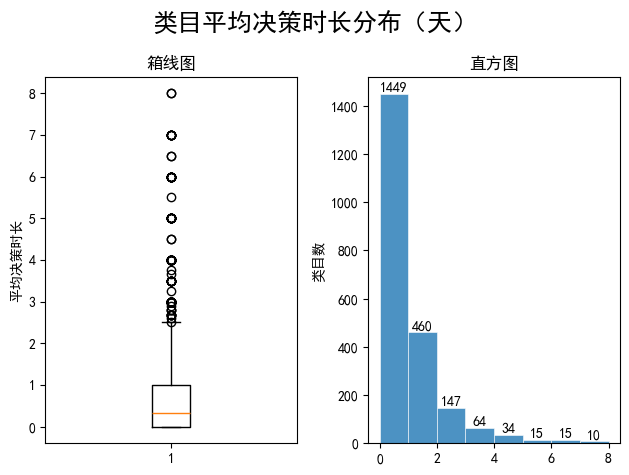

In [169]:
#绘制类目决策时长分布箱线图和直方图
fig,ax = plt.subplots(1,2)
fig.suptitle('类目平均决策时长分布（天）', fontsize = 18, fontweight ='bold')

ax[0].boxplot(category_time_avg['mean'])
ax[0].set_title('箱线图')
ax[0].set_ylabel('平均决策时长')

ax[1].hist(category_time_avg['mean'], bins = range(9), edgecolor = 'white',linewidth = 0.5, alpha = 0.8)
ax[1].bar_label(ax[1].containers[0],fmt = '%d')
ax[1].set_title('直方图')
ax[1].set_ylabel('类目数')

plt.tight_layout()
plt.show()

**类目平均决策时长分析：**
1. 大部分类目的平均决策时长0-1天，即当天完成浏览-消费下单，类目数占比66.04%
   - 这类类目用户决策快，可强化“即时转化”策略，如限时折扣、一键下单、库存紧张提示，快速促成交易；
2. 决策时长在3天以上的类目数量较少，说明少数类目用户决策周期较长；
   - 需通过多触点触达，如收藏后推送优惠、加购后降价或满减提醒、个性化内容种草等来降低决策成本，缩短决策周期；
   - 分析长决策时长类目的品类特性，匹配对应的信任背书内容（如用户评价、专业测评）；
   - 针对长决策时长类目设计差异化运营方案，避免统一策略导致转化流失；

### 6.2.5 关联购买产品

In [171]:
#每个用户一个时间戳下的购买产品种类（也就是每笔订单中都是哪些产品）
cross_1 = df.groupby(['user_id','timestamp','product_id']).size().reset_index()
cross_2 = df.groupby(['user_id','timestamp','product_id']).size().reset_index()

#自连接，获取关联产品
cross_sell = pd.merge(cross_1,cross_2, on=['user_id','timestamp'], how = 'left',suffixes =('_1','_2'))

#筛选product_id1与product_id2不同的记录 以及筛选 a——b组合与b-a组合相同的重复记录
cross= cross_sell[cross_sell['product_id_1'] <cross_sell['product_id_2']]

#关联购买商品分组计数
cross_group = cross.groupby(['product_id_1','product_id_2']).size().reset_index(name='count')
cross_group = cross_group.sort_values('count',ascending = False).head(10)
cross_group

,product_id_1,product_id_2,count
5001,3995514,4139651,25
5163,4139651,4753343,15
5003,3995514,4753343,14
2112,1954678,2405647,10
4851,3815697,3817741,10
616,1257878,1358994,6
4640,3589114,4936201,6
4328,327455,4880707,6
3692,2869062,3777834,5
80,1042152,5062984,4


**6.2.5 关联购买产品组合分析：**
1. 核心关联产品：3995514与4139651的关联购买次数最高（25次），且这两个产品分别与4753343形成关联组合（分别15和14次），说明3995514、4139651、4753343是一组高关联度的产品；
    - 可设置组合套餐（如三款产品打包优惠）提升客单价；
    - 在产品详情页添加“常一起购买”的关联推荐，强化交叉销售；
    - 产品广告推荐位关联，促进关联产品转化；
2. 其他关联组合的关联次数均为（4-10）次，属于中度关联组合；
   - 测试关联推荐位的广告位展示优先级效果，观察是否能提升关联购买次数；
   - 分析这两组产品的用户群体特征，匹配对应的营销活动，增强关联消费意愿